# Training Transformer

### Description
In this assignment, we are tasked with utilizing a transformer decoder-only architecture for pretraining, with a focus on next-token prediction, applied to Pokémon images. Specifically, in testing, if given 60% of an image, predict the remaining part.

Please feel free to mail me if you have any questions.

# Utilities

### Download packages

In [ ]:
!pip install datasets==4.0.0
!pip install -q torchmetrics[image]

### Import Packages

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import AutoModelForCausalLM, GPT2Config, set_seed, LlamaModel, LlamaConfig, MistralModel, MistralConfig

from datasets import load_dataset
from typing import Dict, Any, Optional
import random
import copy
from torchmetrics.image.fid import FrechetInceptionDistance


### Check Devices

In [ ]:
!nvidia-smi

Mon Mar 16 03:38:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             54W /  400W |    2798MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### Set Random Seed

In [ ]:
set_seed(0)

# Prepare Data

### Define Dataset

In [ ]:
from typing import List, Tuple, Union
import torch
from torch.utils.data import Dataset

class PixelSequenceDataset(Dataset):
    def __init__(self, data: List[List[int]], mode: str = "train"):
        """
        A dataset class for handling pixel sequences.

        Args:
            data (List[List[int]]): A list of sequences, where each sequence is a list of integers.
            mode (str): The mode of operation, either "train", "dev", or "test".
                - "train": Returns (input_ids, labels) where input_ids are sequence[:-1] and labels are sequence[1:].
                - "dev": Returns (input_ids, labels) where input_ids are sequence[:-160] and labels are sequence[-160:].
                - "test": Returns only input_ids, as labels are not available.
        """
        self.data = data
        self.mode = mode

    def __len__(self) -> int:
        """Returns the total number of sequences in the dataset."""
        return len(self.data)

    def __getitem__(self, idx: int) -> Union[Tuple[torch.Tensor, torch.Tensor], torch.Tensor]:
        """
        Fetches a sequence from the dataset and processes it based on the mode.

        Args:
            idx (int): The index of the sequence.

        Returns:
            - If mode == "train": Tuple[torch.Tensor, torch.Tensor] -> (input_ids, labels)
            - If mode == "dev": Tuple[torch.Tensor, torch.Tensor] -> (input_ids, labels)
            - If mode == "test": torch.Tensor -> input_ids
        """
        sequence = self.data[idx]

        if self.mode == "train":
            input_ids = torch.tensor(sequence[:-1], dtype=torch.long)
            labels = torch.tensor(sequence[1:], dtype=torch.long)
            return input_ids, labels

        elif self.mode == "dev":
            input_ids = torch.tensor(sequence[:-160], dtype=torch.long)
            labels = torch.tensor(sequence[-160:], dtype=torch.long)
            return input_ids, labels

        elif self.mode == "test":
            input_ids = torch.tensor(sequence, dtype=torch.long)
            return input_ids

        raise ValueError(f"Invalid mode: {self.mode}. Choose from 'train', 'dev', or 'test'.")

### Download Dataset & Prepare Dataloader

In [ ]:
# Load the pokemon dataset from Hugging Face Hub
pokemon_dataset = load_dataset("lca0503/ml2025-hw4-pokemon")

# Load the colormap from Hugging Face Hub
colormap = list(load_dataset("lca0503/ml2025-hw4-colormap")["train"]["color"])

# Define number of classes
num_classes = len(colormap)

# Define batch size
batch_size = 16

# === Prepare Dataset and DataLoader for Training ===
train_dataset: PixelSequenceDataset = PixelSequenceDataset(
    pokemon_dataset["train"]["pixel_color"], mode="train"
)
train_dataloader: DataLoader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

# === Prepare Dataset and DataLoader for Validation ===
dev_dataset: PixelSequenceDataset = PixelSequenceDataset(
    pokemon_dataset["dev"]["pixel_color"], mode="dev"
)
dev_dataloader: DataLoader = DataLoader(
    dev_dataset, batch_size=batch_size, shuffle=False
)

# === Prepare Dataset and DataLoader for Testing ===
test_dataset: PixelSequenceDataset = PixelSequenceDataset(
    pokemon_dataset["test"]["pixel_color"], mode="test"
)
test_dataloader: DataLoader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)

### Visualization

In [ ]:
def pixel_to_image(pixel_color: List[int], colormap: List[List[int]]) -> Image.Image:
    """
    Converts a list of pixel indices into a 20x20 RGB image using a colormap.

    Args:
        pixel_color (List[int]): A list of pixel indices representing colors.
        colormap (List[List[int]]): A list where each index maps to an RGB color [R, G, B].

    Returns:
        Image.Image: A PIL Image object representing the reconstructed image.
    """
    # Ensure the pixel_color list has at least 400 elements (pad with 0s if needed)
    while len(pixel_color) < 400:
        pixel_color.append(0)

    # Map pixel indices to actual RGB colors using the colormap
    pixel_data = [colormap[pixel] for pixel in pixel_color]

    # Convert to numpy array and reshape to 20x20x3 (RGB image)
    image_array = np.array(pixel_data, dtype=np.uint8).reshape(20, 20, 3)

    # Create a PIL Image from the array
    image = Image.fromarray(image_array)

    return image

def show_images(images: List[Image.Image]) -> None:
    """
    Displays a grid of up to 96 images using Matplotlib.

    Args:
        images (List[Image.Image]): A list of PIL Image objects to display.

    Returns:
        None
    """
    num_images = min(96, len(images))  # Limit to 96 images

    # Set up the figure size and grid layout (6 rows, 16 columns)
    fig, axes = plt.subplots(6, 16, figsize=(16, 6))
    axes = axes.flatten()  # Flatten to make iteration easier

    # Loop through images and display each one in the grid
    for i, ax in enumerate(axes):
        if i < num_images:
            ax.imshow(images[i])
            ax.axis('off')  # Hide axis
        else:
            ax.axis('off')  # Hide unused subplots

    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

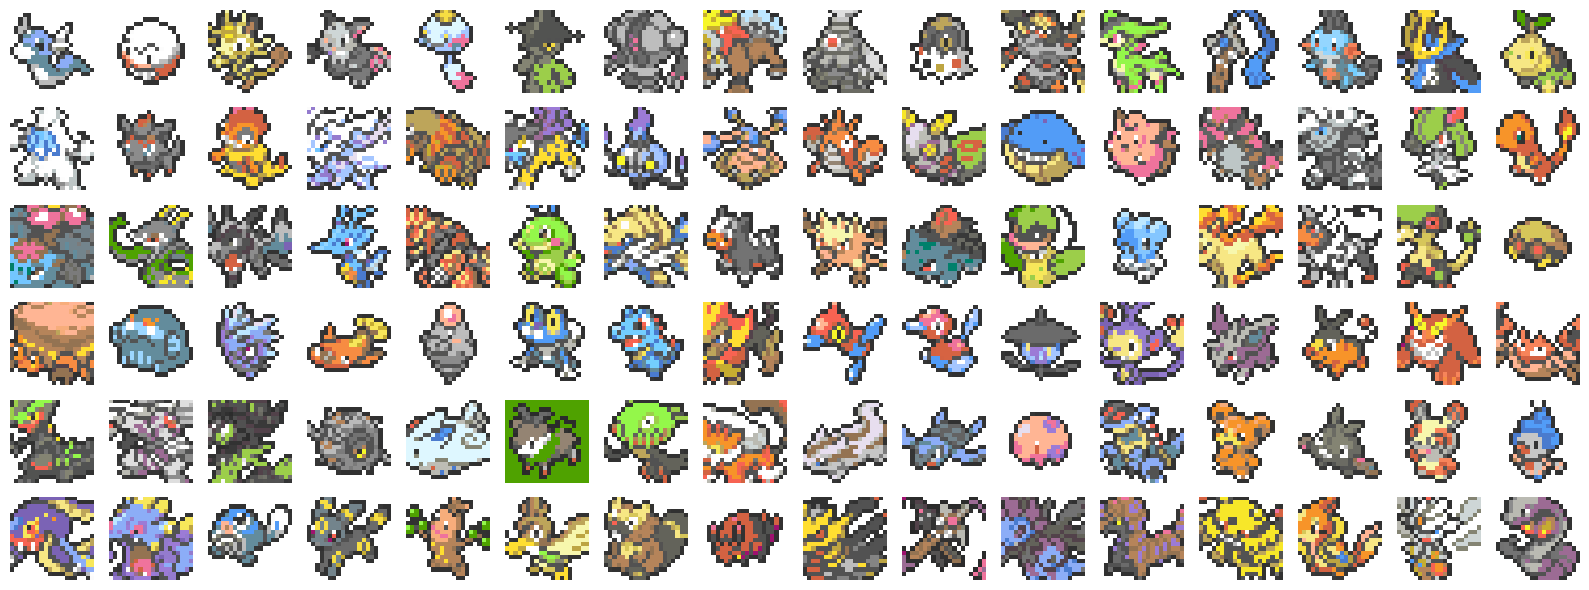

In [ ]:
# Visualize train images
train_images = [pixel_to_image(data["pixel_color"], colormap) for data in pokemon_dataset["train"]]
show_images(train_images)

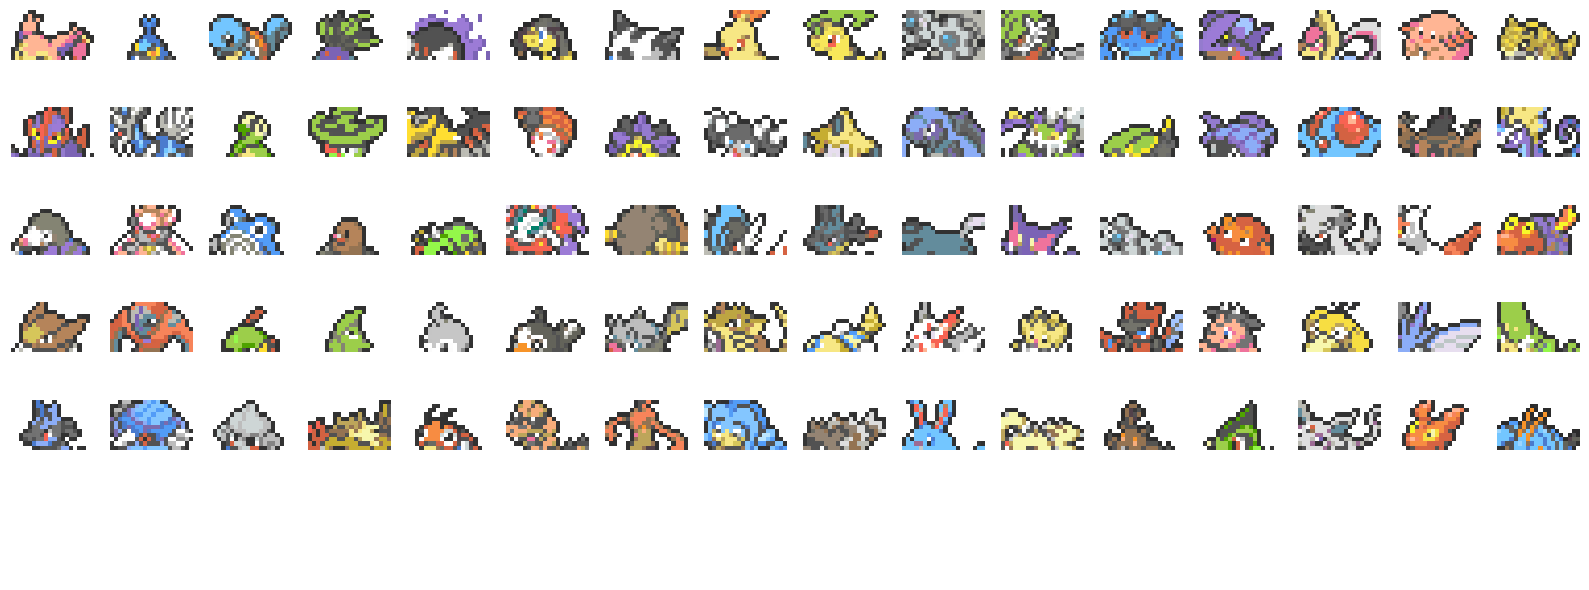

In [ ]:
# Visualize test images
test_images = [pixel_to_image(data["pixel_color"], colormap) for data in pokemon_dataset["test"]]
show_images(test_images)

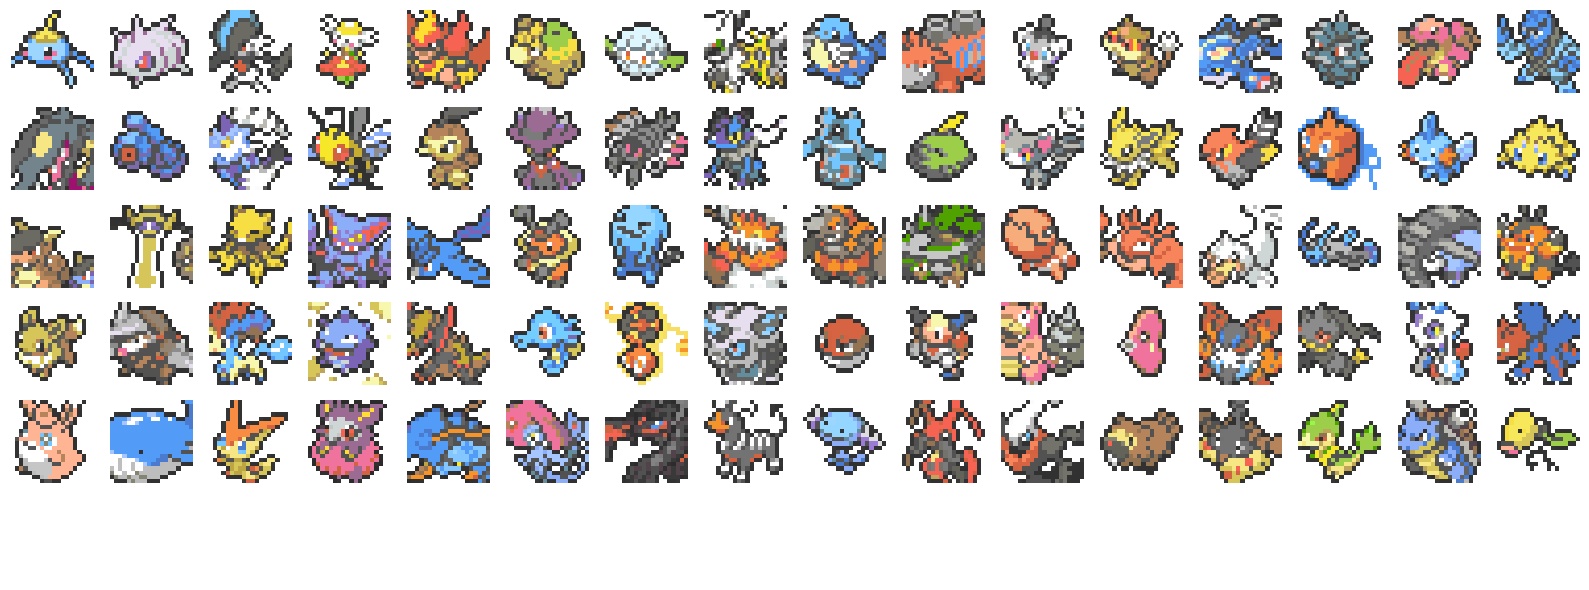

In [ ]:
# Visualize test images
test_images = [pixel_to_image(data["pixel_color"], colormap) for data in pokemon_dataset["dev"]]
show_images(test_images)

# Prepare Model

### Model Configuration
Here, we define the model configuration, including the architecture and key hyperparameters such as the number of attention heads, layers, embedding size, and more.
*   Hint 1: Adjust hyperparameters here for improved performance.
*   Hint 2: Experiment with different model architectures, such as Llama, Mistral, or Qwen, to enhance performance.
  * [LlamaConfig](https://huggingface.co/docs/transformers/model_doc/llama#transformers.LlamaConfig)
  * [MistralConfig](https://huggingface.co/docs/transformers/model_doc/mistral#transformers.MistralConfig)
  * [Qwen2Config](https://huggingface.co/docs/transformers/model_doc/qwen2#transformers.Qwen2Config)

The following sample code uses GPT-2.


In [ ]:
# Define GPT-2 model configuration as a dictionary
gpt2_config = {
    "activation_function": "gelu_new",    # Activation function used in the model
    "architectures": ["GPT2LMHeadModel"],  # Specifies the model type
    "attn_pdrop": 0.1,            # Dropout rate for attention layers
    "embd_pdrop": 0.1,            # Dropout rate for embeddings
    "initializer_range": 0.02,        # Standard deviation for weight initialization
    "layer_norm_epsilon": 1e-05,       # Small constant to improve numerical stability in layer norm
    "model_type": "gpt2",           # Type of model
    "n_ctx": 400,               # Context size (maximum sequence length)
    "n_embd": 256,              # Embedding size
    "n_head": 8,               # Number of attention heads
    "n_layer": 6,              # Number of transformer layers
    "n_positions": 400,           # Maximum number of token positions
    "resid_pdrop": 0.1,           # Dropout rate for residual connections
    "vocab_size": num_classes,       # Number of unique tokens in vocabulary
    "pad_token_id": None,          # Padding token ID (None means no padding token)
    "eos_token_id": None,          # End-of-sequence token ID (None means not explicitly defined)
}

# Load GPT-2 model configuration from dictionary
# config = GPT2Config.from_dict(gpt2_config)

llama_config = {
    "hidden_size": 256,
    "intermediate_size": 1024,
    "num_hidden_layers": 6,
    "num_attention_heads": 8,
    "max_position_embeddings": 400,
    "rms_norm_eps": 1e-5,
    "hidden_act": "silu",
    "attention_dropout": 0.1,
    "hidden_dropout": 0.1,
    "vocab_size": num_classes,
    "initializer_range": 0.02,
    "rope_theta": 10000,
    "pad_token_id": None,
    "eos_token_id": None          # End-of-sequence token ID (None means not explicitly defined)
}

config = LlamaConfig.from_dict(llama_config)

mistral_config = {
    "hidden_size": 256,
    "intermediate_size": 1024,
    "num_hidden_layers": 6,
    "num_attention_heads": 8,
    "max_position_embeddings": 400,
    "rms_norm_eps": 1e-5,
    "hidden_act": "silu",
    "attention_dropout": 0.1,
    "hidden_dropout": 0.1,
    "vocab_size": num_classes,
    "initializer_range": 0.02,
    "rope_theta": 10000,
    "pad_token_id": None,
    "eos_token_id": None          # End-of-sequence token ID (None means not explicitly defined)
}

# config = MistralConfig.from_dict(mistral_config)


### Load Model

In [ ]:
# Load the model using the configuration defined above
model = AutoModelForCausalLM.from_config(config)

print(model)

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable Parameters: {trainable_params:,}")

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(167, 256)
    (layers): ModuleList(
      (0-5): 6 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=256, out_features=256, bias=False)
          (k_proj): Linear(in_features=256, out_features=256, bias=False)
          (v_proj): Linear(in_features=256, out_features=256, bias=False)
          (o_proj): Linear(in_features=256, out_features=256, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=256, out_features=1024, bias=False)
          (up_proj): Linear(in_features=256, out_features=1024, bias=False)
          (down_proj): Linear(in_features=1024, out_features=256, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((256,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((256,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((256,), eps=1e-05)
    (rotary_emb): LlamaRo

# Train and Inference

### Training Arguments
Here, we define the number of epochs for training, the learning rate, the optimizer, and the loss function.
*   Hint 3: Adjust the number of epochs and learning rate here to improve performance.

* Added early stoping = 3


In [ ]:
# TODO
# Training Parameters
epochs = 150                      # Number of training epochs

# learning_rate = 1e-3              # Learning rate for optimizer
learning_rate = 1e-4              # Learning rate for optimizer
# learning_rate = 5e-5              # Learning rate for optimizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")     # Check if CUDA is available for GPU
save_dir = "checkpoints"                               # Directory to save model checkpoints
patience = 3 # Added Patience for early stopping

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()                          # Loss function for classification tasks
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.1) # AdamW optimizer with weight decay

### Save Model Function

In [ ]:
def save_model(model: torch.nn.Module, optimizer: torch.optim.Optimizer, epoch: int, loss: float, save_dir: str, filename: str = "best_model.pth") -> None:
    """
    Saves the model state, optimizer state, current epoch, and loss to a specified directory.

    Args:
        model (torch.nn.Module): The PyTorch model to be saved.
        optimizer (torch.optim.Optimizer): The optimizer whose state will be saved.
        epoch (int): The current epoch number (used for checkpointing).
        loss (float): The current loss value to track model performance.
        save_dir (str): The directory where the model checkpoint will be saved.
        filename (str, optional): The name of the file to save the model. Defaults to "best_model.pth".

    Returns:
        None
    """
    # Construct the full path for saving the model checkpoint
    save_path = os.path.join(save_dir, filename)

    # Save the model, optimizer state, and additional metadata (epoch and loss)
    torch.save({
        'epoch': epoch + 1,                # Save epoch + 1 for easier tracking
        'model_state_dict': model.state_dict(),       # Save model weights
        'optimizer_state_dict': optimizer.state_dict(),  # Save optimizer state (important for resuming training)
        'loss': loss                     # Save the current loss value
    }, save_path)

    # Print a confirmation message indicating the model has been saved
    print(f"Model saved at {save_path} (Loss: {loss:.4f}, Epoch: {epoch + 1})")

## Train

*   Hint 4: Train a classifier to check if an image looks like a Pokémon or not.

Hint: A simple way to build negatives (no extra data)

Use train Pokémon images as positives, and use data augmentation to create negatives by destroying structure. For example, you can generate negatives (you should also explore other strategies and the final grade of this HW will be performance driven)



### Training Generator
We save the checkpoint with the lowest training loss since validation set reconstruction accuracy doesn't directly reflect the model's image generation quality.





In [ ]:
# Create save directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)
# Initialize best loss as positive infinity for comparison during model checkpointing
best_loss: float = float('inf')
# Move model to the appropriate device (GPU or CPU)
model.to(device)
epochs_no_improve = 0

# Training Loop
for epoch in range(epochs):
    model.train()  # Set the model to training mode
    epoch_loss = 0  # Initialize the epoch loss

    # Iterate over training data batches
    for input_ids, labels in tqdm(train_dataloader, desc=f"Training Epoch {epoch + 1}/{epochs}"):
        input_ids, labels = input_ids.to(device), labels.to(device)  # Move data to the same device as the model

        # Forward pass through the model to get logits (output probabilities)
        outputs = model(input_ids=input_ids).logits.view(-1, config.vocab_size)
        labels = labels.view(-1)  # Flatten labels to match logits shape

        # Calculate loss using CrossEntropyLoss
        loss = criterion(outputs, labels)

        # Backpropagation and optimizer step
        optimizer.zero_grad()  # Reset gradients to zero
        loss.backward()     # Compute gradients
        optimizer.step()     # Update model weights

        # Accumulate the loss for the epoch
        epoch_loss += loss.item()

    # Compute average epoch loss
    avg_epoch_loss = epoch_loss / len(train_dataloader)
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_epoch_loss:.4f}")

    # Evaluation Loop (Validation)
    model.eval()      # Set the model to evaluation mode (disables dropout, etc.)
    total_accuracy = 0  # Initialize total accuracy
    num_batches = 0   # Initialize batch counter

    with torch.no_grad():  # Disable gradient calculation for validation
        # Iterate over validation data batches
        for inputs, labels in tqdm(dev_dataloader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)  # Move validation data to device
            attention_mask = torch.ones_like(inputs)          # Attention mask to ensure valid token positions

            # Perform batch inference using the model
            generated_outputs = model.generate(inputs, attention_mask=attention_mask, max_length=400)

            # Extract the last 160 tokens from generated outputs and labels
            generated_outputs = generated_outputs[:, -160:]

            # Calculate accuracy for the batch
            accuracy = (generated_outputs == labels).float().mean().item()
            total_accuracy += accuracy
            num_batches += 1

    # Compute average reconstruction accuracy for the epoch
    avg_accuracy = total_accuracy / num_batches
    print(f"Epoch {epoch + 1}/{epochs}, Reconstruction Accuracy: {avg_accuracy:.4f}")

    # If the current epoch loss is better (lower) than the best loss, save the model
    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss                   # Update best loss
        save_model(model, optimizer, epoch, best_loss, save_dir)  # Save the model with the best loss
        epochs_no_improve = 0
    else:
      epochs_no_improve += 1
      print(f"No improvement for {epochs_no_improve} epochs")

      if epochs_no_improve >= patience:
          print("Early stopping triggered")
          break



Training Epoch 1/150: 100%|██████████| 40/40 [00:01<00:00, 24.25it/s]


Epoch 1/150, Loss: 3.5882


Evaluating: 100%|██████████| 5/5 [00:06<00:00,  1.21s/it]


Epoch 1/150, Reconstruction Accuracy: 0.4100
Model saved at checkpoints/best_model.pth (Loss: 3.5882, Epoch: 1)


Training Epoch 2/150: 100%|██████████| 40/40 [00:01<00:00, 24.27it/s]


...

Epoch 109/150, Reconstruction Accuracy: 0.3427
No improvement for 2 epochs


Training Epoch 110/150: 100%|██████████| 40/40 [00:01<00:00, 24.56it/s]


Epoch 110/150, Loss: 0.0766


Evaluating: 100%|██████████| 5/5 [00:05<00:00,  1.19s/it]

Epoch 110/150, Reconstruction Accuracy: 0.3651
No improvement for 3 epochs
Early stopping triggered


### Inference

In [ ]:
# Load the best model from the saved checkpoint
best_model_path = os.path.join(save_dir, "best_model.pth")              # Path to the best model checkpoint
checkpoint = torch.load(best_model_path, weights_only=True, map_location=device)  # Load checkpoint from the file
model.load_state_dict(checkpoint["model_state_dict"])                  # Load the model weights from checkpoint
model.eval()                                        # Set the model to evaluation mode (disables dropout, etc.)

# Testing Loop with Batch Inference
results: list = []  # List to store the generated sequences from the model

with torch.no_grad():  # Disable gradient calculations for inference
    # Iterate over test data in batches
    for inputs in tqdm(test_dataloader, desc="Generating Outputs"):
        inputs = inputs.to(device)         # Move model to the appropriate device (GPU or CPU)
        attention_mask = torch.ones_like(inputs)  # Attention mask (ensure valid token positions)

        # Generate predictions for the entire batch
        generated_outputs = model.generate(inputs, attention_mask=attention_mask, max_length=400)

        # Convert batch outputs to a list and append to results
        batch_results = generated_outputs.cpu().numpy().tolist()
        results.extend(batch_results)  # Extend the results list with batch results

# Save the results to a file
output_file: str = "reconstructed_results.txt"  # File to save the output sequences
with open(output_file, "w") as f:
    # Write each sequence to the file
    for seq in results:
        f.write(" ".join(map(str, seq)) + "\n")

print(f"Reconstructed results saved to {output_file}")  # Confirmation message

Generating Outputs: 100%|██████████| 5/5 [00:06<00:00,  1.20s/it]

Reconstructed results saved to reconstructed_results.txt


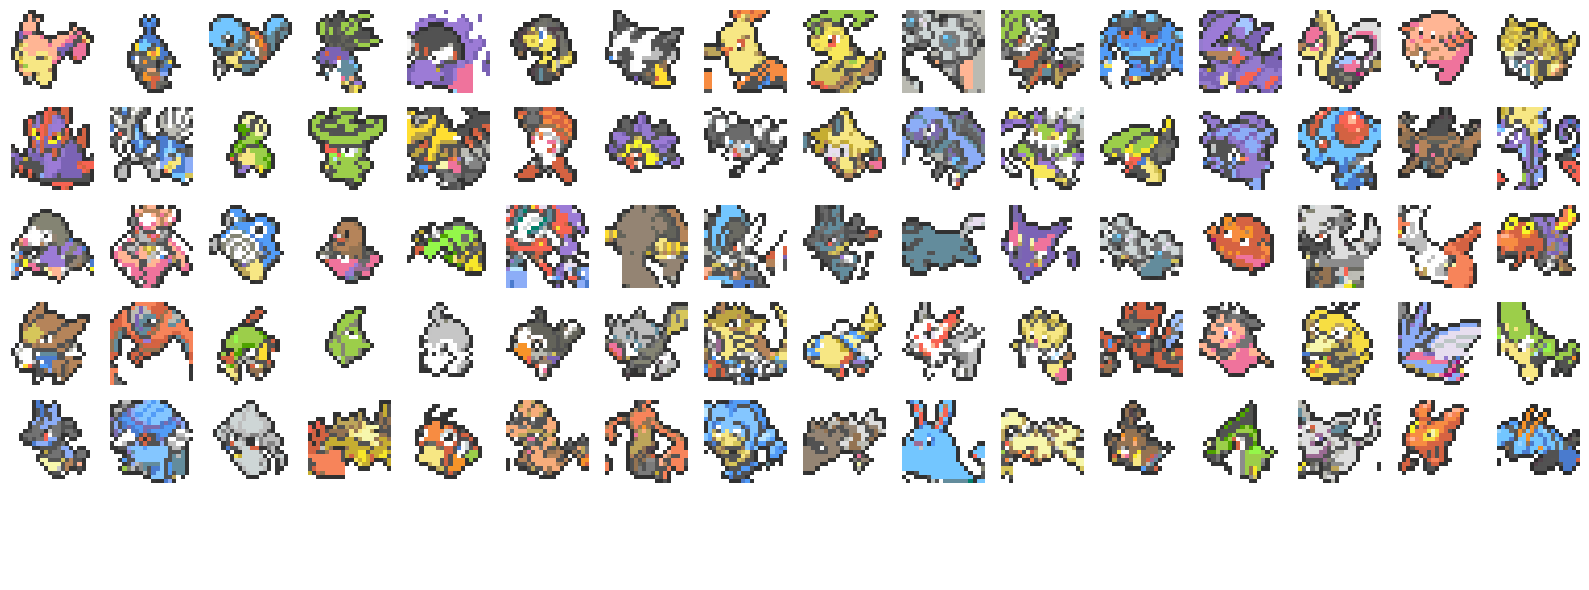

In [ ]:
# Visualize generated test images
predicted_images = [pixel_to_image(sequence, colormap) for sequence in results]
show_images(predicted_images)

###Evaluate your generated results
 * 1. Compute FID between real and generated images. Hint: For convenience, you can first convert everything to RGB tensors. FID is available in multiple packages such as torchmetrics.image.fid.
 * 2. Use your trained classifier to calculate the PDR (Pokemon Detection Rate), (I am changing from the false dicovery rate to PDR).



### Pokemon Classifier

Im implementing classifier of "pokemon image" (1) vs "non pokemon image"(0) using CNN.

Augmentation used:
* random pixel permutation
* random noise tokens
* block shuffle
* Random Huge Cut

In [ ]:
WHITE_TOKEN = 0

def tokens_to_tensor_image(pixel_color, colormap):
    pixel_color = list(pixel_color[:400])

    while len(pixel_color) < 400:
        pixel_color.append(WHITE_TOKEN)

    pixel_data = [colormap[p] for p in pixel_color]
    image_array = np.array(pixel_data, dtype=np.uint8).reshape(20, 20, 3)
    image_tensor = torch.tensor(image_array, dtype=torch.float32).permute(2, 0, 1) / 255.0

    return image_tensor

def permute_pixels(sequence):
    seq = list(sequence[:400])
    random.shuffle(seq)
    return seq

def random_noise_tokens(num_classes, length=400):
    return np.random.randint(0, num_classes, size=length).tolist()

def block_shuffle(sequence, block_size=4):
    arr = np.array(sequence[:400]).reshape(20, 20)

    blocks = []
    for i in range(0, 20, block_size):
        for j in range(0, 20, block_size):
            blocks.append(arr[i:i+block_size, j:j+block_size].copy())

    random.shuffle(blocks)

    out = np.zeros_like(arr)
    idx = 0
    for i in range(0, 20, block_size):
        for j in range(0, 20, block_size):
            out[i:i+block_size, j:j+block_size] = blocks[idx]
            idx += 1

    return out.reshape(-1).tolist()

def huge_white_cut(sequence, white_token=WHITE_TOKEN, min_width=5):
    arr = np.array(sequence[:400]).reshape(20, 20).copy()

    orientation = random.choice(["row", "col"])

    if orientation == "row":
        width = random.randint(min_width, 10)
        start = random.randint(0, 20 - width)
        arr[start:start + width, :] = white_token
    else:
        width = random.randint(min_width, 10)
        start = random.randint(0, 20 - width)
        arr[:, start:start + width] = white_token

    return arr.reshape(-1).tolist()


class PokemonClassifierDataset(Dataset):
    def __init__(self, sequences, colormap, num_classes):
        self.sequences = sequences
        self.colormap = colormap
        self.num_classes = num_classes

    def __len__(self):
        return len(self.sequences) * 2

    def __getitem__(self, idx):
        base_idx = idx // 2
        is_real = (idx % 2 == 0)

        sequence = list(self.sequences[base_idx])

        if is_real:
            img = tokens_to_tensor_image(sequence, self.colormap)
            label = torch.tensor([1.0], dtype=torch.float32)
        else:
            corruption_type = random.choices(
                ["permute", "noise", "block", "huge_cut"],
                weights=[0.2, 0.1, 0.2, 0.5],
                k=1
            )[0]

            if corruption_type == "permute":
                corrupted = permute_pixels(sequence)
            elif corruption_type == "noise":
                corrupted = random_noise_tokens(self.num_classes)
            elif corruption_type == "block":
                corrupted = block_shuffle(sequence)
            else:
                corrupted = huge_white_cut(sequence, white_token=WHITE_TOKEN, min_width=5)

            img = tokens_to_tensor_image(corrupted, self.colormap)
            label = torch.tensor([0.0], dtype=torch.float32)

        return img, label

class PokemonCNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 20 -> 10

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 10 -> 5

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 5 * 5, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


clf_batch_size = 32

clf_train_dataset = PokemonClassifierDataset(
    pokemon_dataset["train"]["pixel_color"],
    colormap=colormap,
    num_classes=num_classes
)

clf_dev_dataset = PokemonClassifierDataset(
    pokemon_dataset["dev"]["pixel_color"],
    colormap=colormap,
    num_classes=num_classes
)

clf_train_loader = DataLoader(clf_train_dataset, batch_size=clf_batch_size, shuffle=True)
clf_dev_loader = DataLoader(clf_dev_dataset, batch_size=clf_batch_size, shuffle=False)

classifier_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pokemon_clf = PokemonCNNClassifier().to(classifier_device)

clf_criterion = nn.BCEWithLogitsLoss()
clf_optimizer = optim.Adam(pokemon_clf.parameters(), lr=1e-3)

def evaluate_classifier(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            total_loss += loss.item() * images.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

clf_epochs = 15
best_dev_acc = 0.0
best_clf_state = None

for epoch in range(clf_epochs):
    pokemon_clf.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for images, labels in clf_train_loader:
        images = images.to(classifier_device)
        labels = labels.to(classifier_device)

        clf_optimizer.zero_grad()
        logits = pokemon_clf(images)
        loss = clf_criterion(logits, labels)
        loss.backward()
        clf_optimizer.step()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        running_loss += loss.item() * images.size(0)
        running_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    train_loss = running_loss / total_samples
    train_acc = running_correct / total_samples

    dev_loss, dev_acc = evaluate_classifier(
        pokemon_clf,
        clf_dev_loader,
        clf_criterion,
        classifier_device
    )

    print(
        f"[Classifier] Epoch {epoch+1:02d}/{clf_epochs} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"dev_loss={dev_loss:.4f}, dev_acc={dev_acc:.4f}"
    )

    if dev_acc > best_dev_acc:
        best_dev_acc = dev_acc
        best_clf_state = copy.deepcopy(pokemon_clf.state_dict())

pokemon_clf.load_state_dict(best_clf_state)
pokemon_clf.eval()

print(f"Best classifier dev accuracy: {best_dev_acc:.4f}")

[Classifier] Epoch 01/15 | train_loss=0.6709, train_acc=0.5957 | dev_loss=0.5373, dev_acc=0.7625
[Classifier] Epoch 02/15 | train_loss=0.3589, train_acc=0.8497 | dev_loss=0.2518, dev_acc=0.9062
[Classifier] Epoch 03/15 | train_loss=0.2233, train_acc=0.9248 | dev_loss=0.1893, dev_acc=0.9250
[Classifier] Epoch 04/15 | train_loss=0.1796, train_acc=0.9359 | dev_loss=0.1275, dev_acc=0.9375
[Classifier] Epoch 05/15 | train_loss=0.1288, train_acc=0.9565 | dev_loss=0.1504, dev_acc=0.9563
[Classifier] Epoch 06/15 | train_loss=0.1435, train_acc=0.9478 | dev_loss=0.1451, dev_acc=0.9563
[Classifier] Epoch 07/15 | train_loss=0.0956, train_acc=0.9620 | dev_loss=0.0928, dev_acc=0.9563
[Classifier] Epoch 08/15 | train_loss=0.0929, train_acc=0.9676 | dev_loss=0.1076, dev_acc=0.9625
[Classifier] Epoch 09/15 | train_loss=0.0969, train_acc=0.9644 | dev_loss=0.1182, dev_acc=0.9563
[Classifier] Epoch 10/15 | train_loss=0.0787, train_acc=0.9691 | dev_loss=0.0566, dev_acc=0.9750
[Classifier] Epoch 11/15 | tra

The CNN Classifier is created with accuracy 0.975 on the dev set.

In [ ]:


def sequences_to_image_batch(sequences, colormap, white_token=0):
    """
    Convert a list of token sequences into a float tensor of shape (N, 3, 20, 20),
    scaled to [0,1].
    """
    images = []

    for seq in sequences:
        seq = list(seq[:400])
        while len(seq) < 400:
            seq.append(white_token)

        pixel_data = [colormap[p] for p in seq]
        image_array = np.array(pixel_data, dtype=np.uint8).reshape(20, 20, 3)
        image_tensor = torch.tensor(image_array, dtype=torch.float32).permute(2, 0, 1) / 255.0
        images.append(image_tensor)

    return torch.stack(images, dim=0)

def compute_fid_score(real_sequences, generated_sequences, colormap, device, batch_size=32):
    """
    Compute FID between real Pokemon token sequences and generated token sequences.
    """
    fid = FrechetInceptionDistance(
        feature=2048,
        reset_real_features=True,
        normalize=True
    ).to(device)

    real_batch = sequences_to_image_batch(real_sequences, colormap).to(device)
    fake_batch = sequences_to_image_batch(generated_sequences, colormap).to(device)

    with torch.no_grad():
        for i in range(0, real_batch.size(0), batch_size):
            fid.update(real_batch[i:i+batch_size], real=True)

        for i in range(0, fake_batch.size(0), batch_size):
            fid.update(fake_batch[i:i+batch_size], real=False)

    score = fid.compute().item()
    return score

real_sequences = pokemon_dataset["dev"]["pixel_color"][:100]
fake_sequences = results[:100]

fid_score = compute_fid_score(
    real_sequences=real_sequences,
    generated_sequences=fake_sequences,
    colormap=colormap,
    device=classifier_device,
    batch_size=32
)

print("FID:", fid_score)

FID: 74.17987060546875


In [ ]:
def generated_tokens_to_tensor_batch(generated_sequences, colormap, white_token=0):
    """
    Convert a list of generated token sequences into a tensor batch of shape (N, 3, 20, 20).
    """
    image_tensors = []

    for seq in generated_sequences:
        seq = list(seq[:400])
        while len(seq) < 400:
            seq.append(white_token)

        pixel_data = [colormap[p] for p in seq]
        image_array = np.array(pixel_data, dtype=np.uint8).reshape(20, 20, 3)
        image_tensor = torch.tensor(image_array, dtype=torch.float32).permute(2, 0, 1) / 255.0
        image_tensors.append(image_tensor)

    return torch.stack(image_tensors, dim=0)


def compute_pdr(classifier_model, generated_sequences, colormap, device, threshold=0.5, batch_size=32):
    """
    Compute Pokemon Detection Rate (PDR) for generated token sequences.

    PDR = fraction of generated images classified as Pokemon.
    """
    classifier_model.eval()

    batch_tensor = generated_tokens_to_tensor_batch(generated_sequences, colormap).to(device)

    total_positive = 0
    total_count = 0
    all_probs = []

    with torch.no_grad():
        for i in range(0, batch_tensor.size(0), batch_size):
            batch = batch_tensor[i:i+batch_size]
            logits = classifier_model(batch)
            probs = torch.sigmoid(logits).squeeze(1)

            preds = (probs >= threshold).float()

            total_positive += preds.sum().item()
            total_count += preds.numel()
            all_probs.extend(probs.cpu().tolist())

    pdr = total_positive / total_count
    mean_prob = sum(all_probs) / len(all_probs)

    return {
        "PDR": pdr,
        "mean_classifier_prob": mean_prob,
        "num_samples": total_count
    }

In [ ]:
pdr_result = compute_pdr(
    classifier_model=pokemon_clf,
    generated_sequences=results,
    colormap=colormap,
    device=classifier_device,
    threshold=0.5,
    batch_size=32
)

print(pdr_result)


{'PDR': 0.95, 'mean_classifier_prob': 0.932156003790442, 'num_samples': 80}


###Summarize your Implementation

In this assignment key point that I did:

[Model Tuning]
* Testing different transformer model (GPT2, Llama and Mistral)

* Testing different hyperparameter (Number of Context, Number of embedding, Number of layer and number of head) using 3 different set as follow :

| Model Size | n_ctx | n_embd | n_layer | n_head |
|-------------|------|--------|---------|--------|
| Small       | 128  | 64     | 2       | 2      |
| Medium      | 256  | 128    | 4       | 4      |
| Large       | 400  | 256    | 6       | 8      |


[Model Training Loop]
* Implemented early stoping with patience = 3 epoch
Training
* Testing different epoch and learning rate:

| Training Size | Epoch | Learning Rate |
|-------------|------|---------------|
| Small       | 100  | 1e-3 |
| Medium      | 150  | 1e-4 |
| Large       | 200  | 5e-5 |



[Eval]
* Creating Pokemon Classificiation using CNN with negative data augmented by shuffling pixel, swap, noice and big cut resulted to 97.5% accuracy
* Implemented FID and PDR (using CNN Model) for evaluation
* Visual comparison between the generated image on dev set

### Result
Attempt log sorted by FID Score
| ID | Config | Arch | n_ctx | n_embd | n_layer | n_head | Epoch | LR | Reconstruction Accuracy | Last Epoch | FID | PDR | Mean Classifier Prob |
|----|--------|------|------|--------|---------|--------|------|------|-------------------------|-----------|------|------|-----------|
| 6 | Llama | LlamaForCausalLM | 400 | 256 | 6 | 8 | 150 | 1e-4 | 0.3693 | 93 | 74.8571 | 0.95 | 0.9300 |
| 7 | Mistral | MistralForCausalLM | 400 | 256 | 6 | 8 | 150 | 1e-4 | 0.3648 | 90 | 75.2056 | 0.875 | 0.8606 |
| 8 | Llama | LlamaForCausalLM | 400 | 256 | 6 | 8 | 100 | 1e-3 | 0.3850 | 64 | 77.0100 | 0.9625 | 0.9350 |
| 9 | Mistral | MistralForCausalLM | 400 | 256 | 6 | 8 | 100 | 1e-3 | 0.3858 | 74 | 77.7000 | 0.9500 | 0.9420 |
| 5 | GPT2 | GPT2LMHeadModel | 400 | 256 | 6 | 8 | 150 | 1e-4 | 0.3758 | 150 | 77.7372 | 0.9625 | 0.9512 |
| 11 | Mistral | MistralForCausalLM | 400 | 256 | 6 | 8 | 200 | 5e-5 | 0.3475 | 142 | 77.7617 | 0.9625 | 0.9575 |
| 10 | Llama | LlamaForCausalLM | 400 | 256 | 6 | 8 | 200 | 5e-5 | 0.3412 | 152 | 78.0220 | 0.8750 | 0.8557 |
| 4 | GPT2 | GPT2LMHeadModel | 400 | 256 | 6 | 8 | 100 | 1e-3 | 0.3630 | 100 | 79.4030 | 0.9625 | 0.9575 |
| 12 | GPT2 | GPT2LMHeadModel | 400 | 256 | 6 | 8 | 200 | 5e-5 | 0.3612 | 150 | 85.2437 | 0.9000 | 0.8703 |
| 3 | GPT2 | GPT2LMHeadModel | 400 | 256 | 6 | 8 | 50 | 1e-3 | 0.3600 | 50 | 87.2684 | 0.7750 | 0.7979 |
| 2 | GPT2 | GPT2LMHeadModel | 256 | 128 | 4 | 4 | 50 | 1e-3 | 0.3323 | 50 | 88.9783 | 0.7750 | 0.7628 |
| 1 | GPT2 | GPT2LMHeadModel | 128 | 64 | 2 | 2 | 50 | 1e-3 | 0.3400 | 50 | 90.8031 | 0.7000 | 0.7000 |

Key insight:
* During initial running we can see the improvement in result when increasing the transformer condiguration to bigger model. Need to note that due to computation limit, I am unable to increase the transformer configuration further. Thus I settle on the **configuration large hyperparameter.**
* Using larger transformer, I did different training loop parameter. **Initially decreasing learning rate hurt the result**. This happened because the model not yet converges when maximum epoch reached, thus i tried with bigger number of epoch. In this case the optimal number of epoch and learning rate is **Medium Traning Loop**
* Lastly, I tried comparing different model with **Large transformer configuration and various training loop.** Generally Llama model is better than Mistral, followed by GPT2.

Overall we can see that the best model achieved on model 6: using LLama with large transformer and medium training loop. In addition to the result matrix, visually model 6 is the model with generated image looks pokemon-like.



### Relevant Generated Image/Model Result

* Best output : Model 6
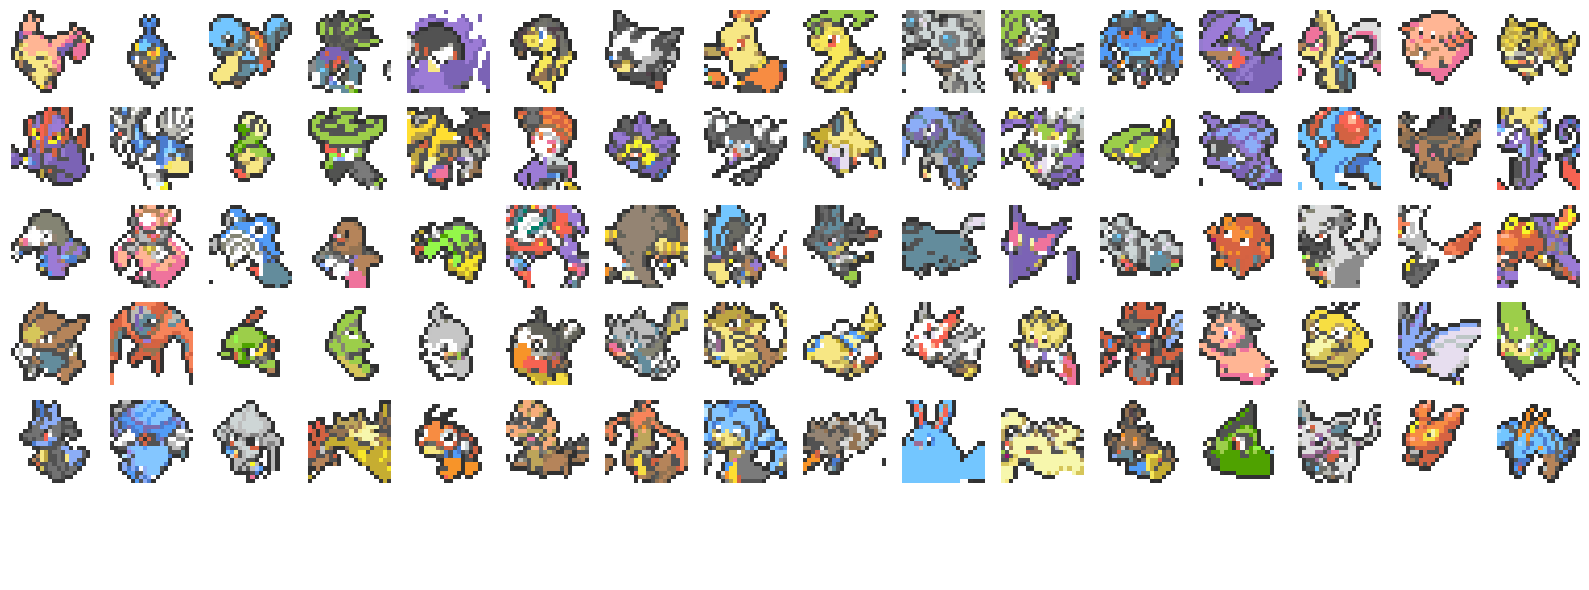


* Best Mistral Output: Model 7
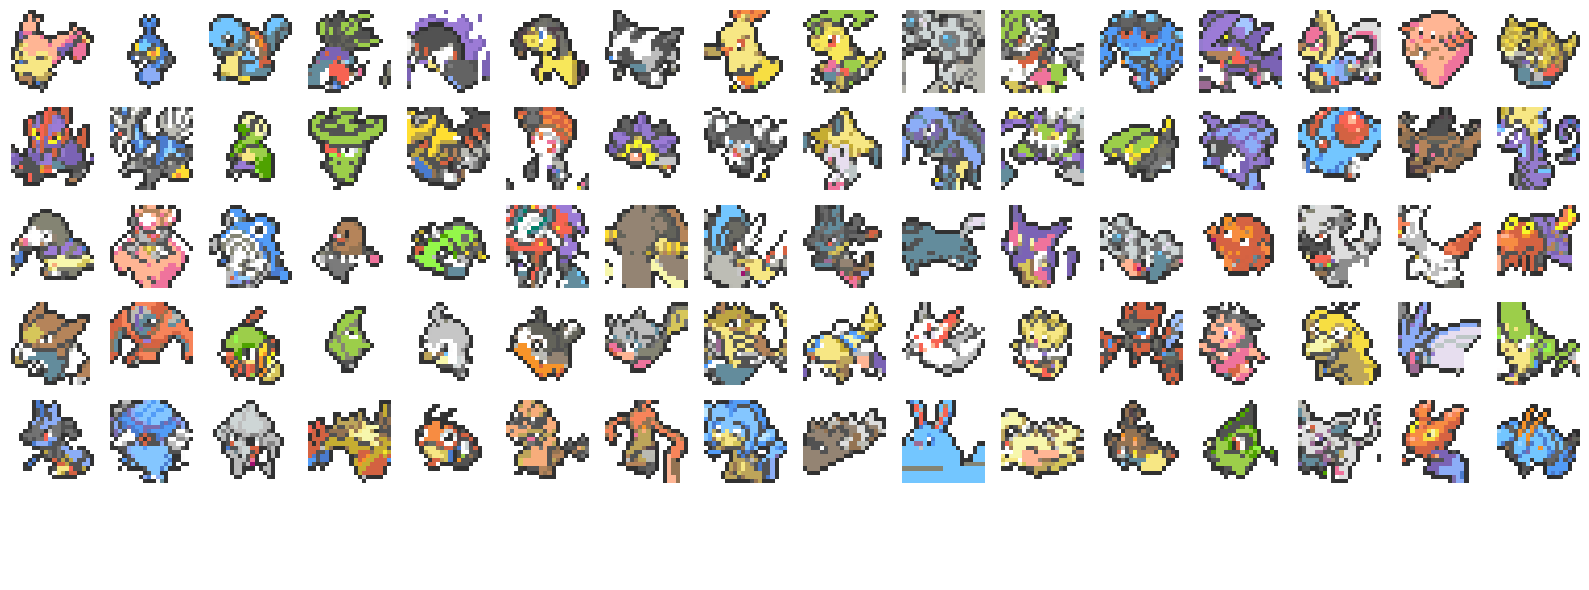

* Best GPT Output: Model 5
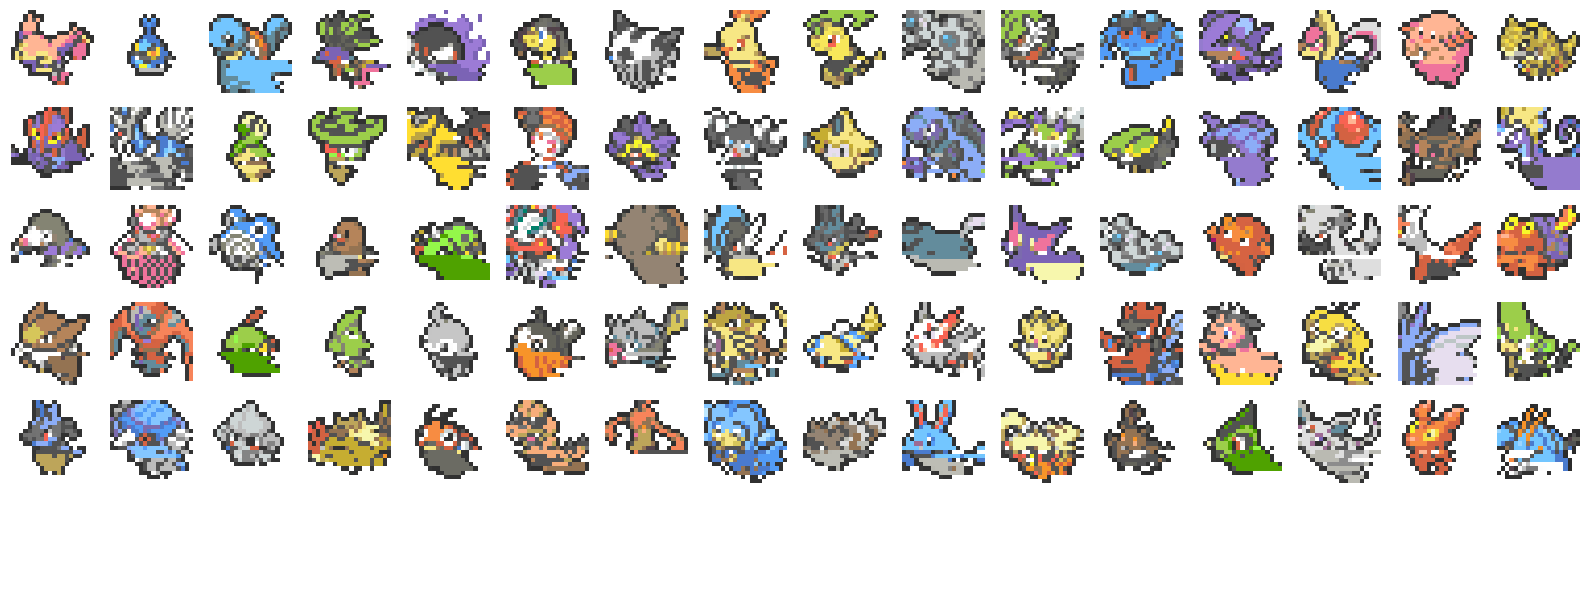

* Medium Transformer Result: Model 2
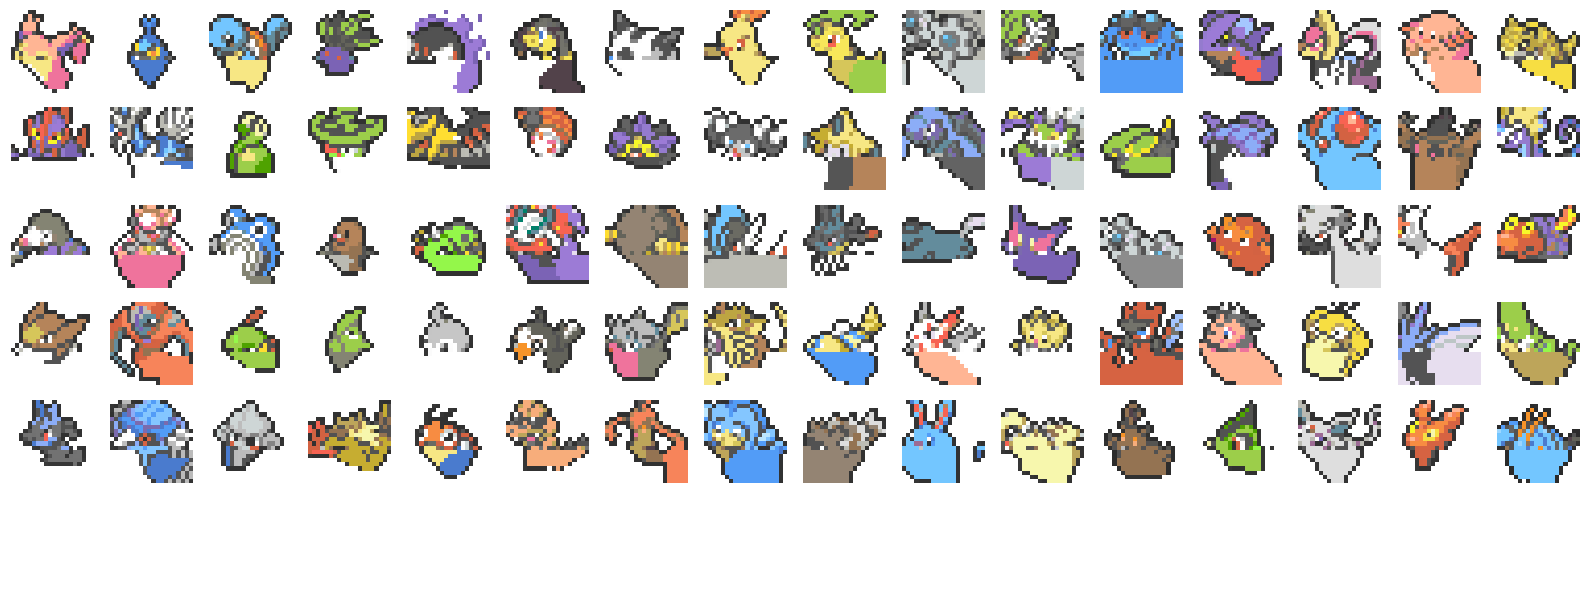